```{index} disjunctive programming
```
```{index} single: application; electric vehicles
```
```{index} single: solver; highs
```
```{index} single: AMPL; Set
```
```{index} pandas dataframe
```
# Recharging strategy for an electric vehicle

Whether it is to visit family, take a sightseeing tour or call on business associates, planning a road trip is a familiar and routine task. Here we consider a road trip on a pre-determined route for which need to plan rest and recharging stops. This example demonstrates use of AMPL disjunctions to model the decisions on where to stop.

In [13]:
# install dependencies and select solver
%pip install -q amplpy pandas numpy matplotlib

SOLVER = "highs"

from amplpy import AMPL, ampl_notebook

ampl = ampl_notebook(
    modules=["highs"],  # modules to install
    license_uuid="default",  # license to use
)  # instantiate AMPL object and register magics

Using default Community Edition License for Colab. Get yours at: https://ampl.com/ce
Licensed to AMPL Community Edition License for the AMPL Model Colaboratory (https://ampl.com/colab).


## Problem Statement

Given the current location $x$, battery charge $c$, and planning horizon $D$, the task is to plan a series of recharging and rest stops. Data is provided for the location and the charging rate available at each charging stations. The objective is to drive from location $x$ to location $x + D$ in as little time as possible subject to the following constraints:

* To allow for unforeseen events, the state of charge should never drop below 20% of the maximum capacity.
* The the maximum charge is $c_{max} = 80$ kWh.
* For comfort, no more than 4 hours should pass between stops, and that a rest stop should last at least $t^{rest}$.
* Any stop includes a $t^{lost} = 10$ minutes of "lost time".

For this first model we make several simplifying assumptions that can be relaxed as a later time.

* Travel is at a constant speed $v = 100$ km per hour and a constant discharge rate $R = 0.24$ kWh/km
* The batteries recharge at a constant rate determined by the charging station.
* Only consider stops at the recharging stations.

## Modeling

The problem statement identifies four state variables.

* $c$ the current battery charge
* $r$ the elapsed time since the last rest stop
* $t$ elapsed time since the start of the trip
* $x$ the current location

The charging stations are located at positions $d_i$ for $i\in I$ with capacity $C_i$. The arrival time at charging station $i$ is given by

$$
\begin{align*}
c_i^{arr} & = c_{i-1}^{dep} - R (d_i - d_{i-1}) \\
r_i^{arr} & = r_{i-1}^{dep} + \frac{d_i - d_{i-1}}{v} \\
t_i^{arr} & = t_{i-1}^{dep} + \frac{d_i - d_{i-1}}{v} \\
\end{align*}
$$

where the script $t_{i-1}^{dep}$ refers to departure from the prior location. At each charging location there is a decision to make of whether to stop, rest, and recharge. If the decision is positive, then

$$
\begin{align*}
c_i^{dep} & \leq c^{max} \\
r_i^{dep} & = 0 \\
t_i^{dep} & \geq t_{i}^{arr} + t_{lost} + \frac{c_i^{dep} - c_i^{arr}}{C_i} \\
t_i^{dep} & \geq t_{i}^{arr} + t_{rest}
\end{align*}
$$

which account for the battery charge, the lost time and time required for battery charging, and allows for a minimum rest time. On the other hand, if a decision is make to skip the charging and rest opportunity,

$$
\begin{align*}
c_i^{dep} & = c_i^{arr} \\
r_i^{dep} & = r_i^{arr} \\
t_i^{dep} & = t_i^{arr}
\end{align*}
$$

The latter sets of constraints have an exclusive-or relationship. That is, either one or the other of the constraint sets hold, but not both.  

$$
\begin{align*}
\min \quad & t_{n+1}^{arr} \\
\text{s.t.} \quad
    & r_i^{arr}  \leq r^{max} & \forall \, i \in I \\
    & c_i^{arr}  \geq c^{min} & \forall \,i \in I \\
    & c_i^{arr}  = c_{i-1}^{dep} - R (d_i - d_{i-1}) & \forall \,i \in I \\
    & r_i^{arr}  = r_{i-1}^{dep} + \frac{d_i - d_{i-1}}{v} & \forall \,i \in I \\
    & t_i^{arr}  = t_{i-1}^{dep} + \frac{d_i - d_{i-1}}{v} & \forall \,i \in I \\
& \begin{bmatrix}
    c_i^{dep} & \leq & c^{max} \\
    r_i^{dep} & = & 0 \\
    t_i^{dep} & \geq & t_{i}^{arr} + t_{lost} + \frac{c_i^{dep} - c_i^{arr}}{C_i} \\
    t_i^{dep} & \geq & t_{i}^{arr} + t_{rest}
\end{bmatrix}
\veebar
\begin{bmatrix}
    c_i^{dep} = c_i^{arr} \\
    r_i^{dep} = r_i^{arr} \\
    t_i^{dep} = t_i^{arr}
\end{bmatrix} & \forall \, i \in I.
\end{align*}
$$


## Charging Station Information

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# specify number of charging stations
n_charging_stations = 20

# randomly distribute charging stations along a fixed route
np.random.seed(1842)
d = np.round(np.cumsum(np.random.triangular(20, 150, 223, n_charging_stations)), 1)

# randomly assign changing capacities
c = np.random.choice([50, 100, 150, 250], n_charging_stations, p=[0.2, 0.4, 0.3, 0.1])

# assign names to the charging stations
s = [f"S_{i:02d}" for i in range(n_charging_stations)]

stations = pd.DataFrame([s, d, c]).T
stations.columns = ["name", "location", "kw"]
display(stations)

,name,location,kw
0,S_00,191.6,150
1,S_01,310.6,100
2,S_02,516.0,50
3,S_03,683.6,50
4,S_04,769.9,50
5,S_05,869.7,100
6,S_06,1009.1,150
7,S_07,1164.7,100
8,S_08,1230.8,100
9,S_09,1350.8,250


## Route Information

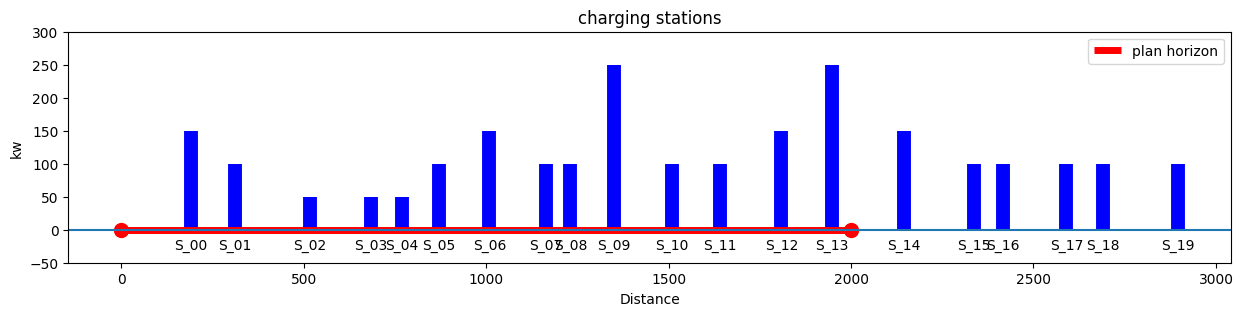

In [15]:
# current location (km) and charge (kw)
x = 0

# planning horizon
D = 2000

# visualize
fig, ax = plt.subplots(1, 1, figsize=(15, 3))


def plot_stations(stations, x, D, ax=ax):
    for station in stations.index:
        xs = stations.loc[station, "location"]
        ys = stations.loc[station, "kw"]
        ax.plot([xs, xs], [0, ys], "b", lw=10, solid_capstyle="butt")
        ax.text(xs, 0 - 30, stations.loc[station, "name"], ha="center")

    ax.plot([x, x + D], [0, 0], "r", lw=5, solid_capstyle="butt", label="plan horizon")
    ax.plot([x, x + D], [0, 0], "r.", ms=20)

    ax.axhline(0)
    ax.set_ylim(-50, 300)
    ax.set_xlabel("Distance")
    ax.set_ylabel("kw")
    ax.set_title("charging stations")
    ax.legend()


plot_stations(stations, x, D)

## Car Information

In [16]:
# charge limits (kw)
c_max = 150
c_min = 0.2 * c_max
c = c_max

# velocity km/hr and discharge rate kwh/km
v = 100.0
R = 0.24

# lost time
t_lost = 10 / 60
t_rest = 10 / 60

# rest time
r_max = 3

## AMPL Model

In [17]:
%%writefile ev_plan.mod

param n;

# locations and road segments between location x and x + D
set STATIONS;  # 1..n
set LOCATIONS; # 0, 1..n, D
set SEGMENTS;  # 1..n + 1

param C{STATIONS};
param D;
param c_min;
param c_max;
param v;
param R;

param r_max;
param location{LOCATIONS};
param dist{SEGMENTS};
param t_lost;

# distance traveled
var x{LOCATIONS} >= 0, <= 10000;

# arrival and departure charge at each charging station
var c_arr{LOCATIONS} >= c_min, <= c_max;
var c_dep{LOCATIONS} >= c_min, <= c_max;

# arrival and departure times from each charging station
var t_arr{LOCATIONS} >= 0, <= 100;
var t_dep{LOCATIONS} >= 0, <= 100;

# arrival and departure rest from each charging station
var r_arr{LOCATIONS} >= 0, <= r_max;
var r_dep{LOCATIONS} >= 0, <= r_max;

minimize min_time: t_arr[n + 1];

s.t. drive_time {i in SEGMENTS}: t_arr[i] == t_dep[i-1] + dist[i]/v;
s.t. rest_time {i in SEGMENTS}: r_arr[i] == r_dep[i-1] + dist[i]/v;
s.t. drive_distance {i in SEGMENTS}: x[i] == x[i-1] + dist[i];
s.t. discharge {i in SEGMENTS}: c_arr[i] == c_dep[i-1] - R * dist[i];

s.t. recharge {i in STATIONS}:
    # list of constraints that apply if there is no stop at station i
    ((c_dep[i] == c_arr[i] and t_dep[i] == t_arr[i] and r_dep[i] == r_arr[i])
    or
    # list of constraints that apply if there is a stop at station i
    (t_dep[i] == t_lost + t_arr[i] + (c_dep[i] - c_arr[i])/C[i] and
        c_dep[i] >= c_arr[i] and r_dep[i] == 0))
    and not
    ((c_dep[i] == c_arr[i] and t_dep[i] == t_arr[i] and r_dep[i] == r_arr[i])
    and
    (t_dep[i] == t_lost + t_arr[i] + (c_dep[i] - c_arr[i])/C[i] and
        c_dep[i] >= c_arr[i] and r_dep[i] == 0));

Overwriting ev_plan.mod


In [18]:
def ev_plan(stations, x, D):
    # data preprocessing

    # find stations between x and x + D
    on_route = stations[(stations["location"] >= x) & (stations["location"] <= x + D)]

    # adjust the index to match the model directly
    on_route.index += 1

    n = len(on_route)

    # get the values of the location parameter
    location = on_route["location"].to_dict()
    location[0] = x
    location[n + 1] = x + D

    # get the values for the dist parameter
    dist = {}
    for s in range(1, n + 2):
        dist[s] = location[s] - location[s - 1]

    # define the indexing sets
    # note the +1 at the end because Python ranges are not inclusive at the endpoint
    STATIONS = list(range(1, n + 1))  # 1 to n
    LOCATIONS = list(range(n + 2))  # 0 to n + 1
    SEGMENTS = list(range(1, n + 2))  # 1 to n + 1

    # instantiate AMPL and load model
    m = AMPL()
    m.read("ev_plan.mod")

    m.set["STATIONS"] = STATIONS
    m.set["LOCATIONS"] = LOCATIONS
    m.set["SEGMENTS"] = SEGMENTS

    # load data
    m.param["C"] = on_route["kw"]
    m.param["location"] = location
    m.param["D"] = D
    m.param["n"] = n
    m.param["c_min"] = c_min
    m.param["c_max"] = c_max
    m.param["r_max"] = r_max
    m.param["t_lost"] = t_lost
    m.param["v"] = v
    m.param["R"] = R
    m.param["dist"] = dist

    # initial conditions
    m.var["x"][0].fix(x)
    m.var["t_dep"][0].fix(0.0)
    m.var["r_dep"][0].fix(0.0)
    m.var["c_dep"][0].fix(c)

    # set solver and solve
    m.solve(solver=SOLVER)
    assert m.solve_result == "solved", m.solve_result

    return m


def get_results(model):
    x = [(int(k), v) for k, v in model.var["x"].to_list()]
    t_arr = [v for k, v in model.var["t_arr"].to_list()]
    t_dep = [v for k, v in model.var["t_dep"].to_list()]
    c_arr = [v for k, v in model.var["c_arr"].to_list()]
    c_dep = [v for k, v in model.var["c_dep"].to_list()]

    results = pd.DataFrame(x, columns=["index", "location"]).set_index("index")
    results["t_arr"] = t_arr
    results["t_dep"] = t_dep
    results["c_arr"] = c_arr
    results["c_dep"] = c_dep
    results["t_stop"] = results["t_dep"] - results["t_arr"]
    results["t_stop"] = results["t_stop"].round(6)

    return results


m = ev_plan(stations, 0, 2000)
results = get_results(m)
display(results)

HiGHS 1.10.0: HiGHS 1.10.0: optimal solution; objective 24.142507
9961 simplex iterations
116 branching nodes


,location,t_arr,t_dep,c_arr,c_dep,t_stop
index,,,,,,
0,0.0,0.000000,0.000000,30.0000,150.0000,0.000000
1,191.6,1.916000,2.389227,104.0160,150.0000,0.473227
2,310.6,3.579227,4.031493,121.4400,150.0000,0.452267
3,516.0,6.085493,6.252162,100.7040,100.7041,0.166669
4,683.6,7.928162,7.928162,60.4801,60.4801,0.000000
5,769.9,8.791162,9.241507,39.7681,53.9520,0.450345
6,869.7,10.239507,10.740733,30.0000,63.4560,0.501227
7,1009.1,12.134733,12.848119,30.0000,112.0079,0.713386
8,1164.7,14.404119,14.404119,74.6639,74.6639,-0.000000


HiGHS 1.10.0: HiGHS 1.10.0: optimal solution; objective 24.142507
9961 simplex iterations
116 branching nodes


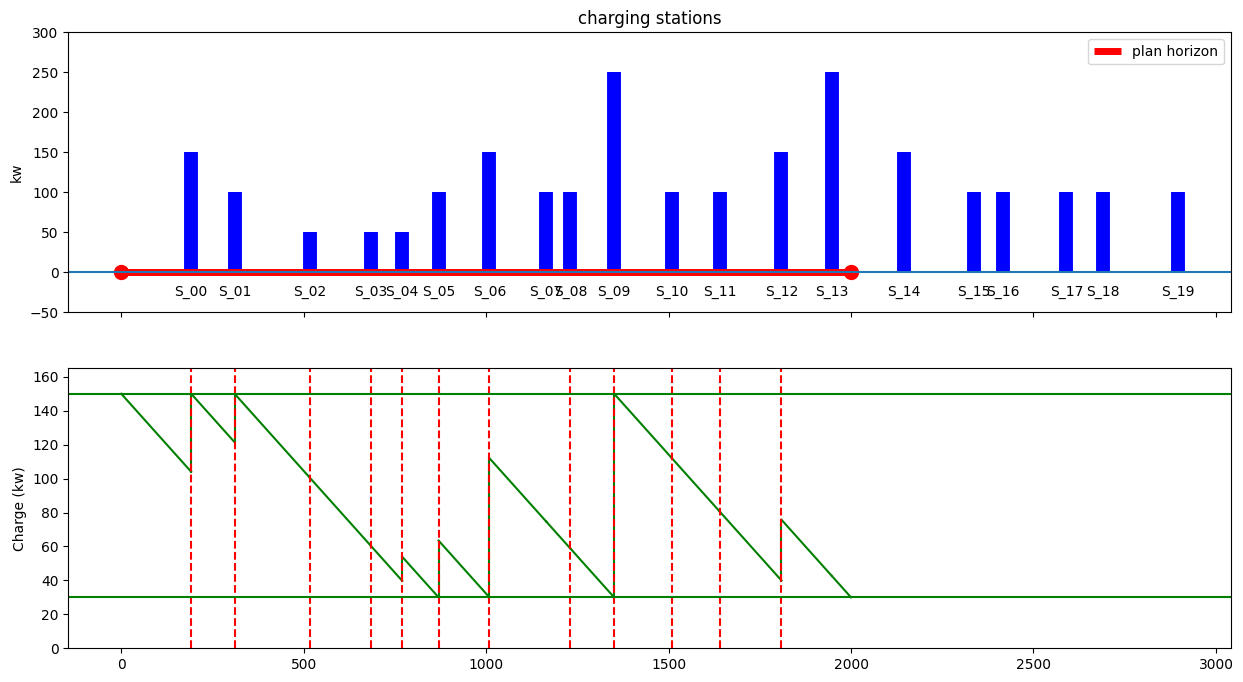

In [19]:
# visualize


def visualize(m):
    D = m.param["D"].value()

    results = get_results(m)

    results["t_stop"] = results["t_dep"] - results["t_arr"]

    fig, ax = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

    # plot stations
    for station in stations.index:
        xs = stations.loc[station, "location"]
        ys = stations.loc[station, "kw"]
        ax[0].plot([xs, xs], [0, ys], "b", lw=10, solid_capstyle="butt")
        ax[0].text(xs, 0 - 30, stations.loc[station, "name"], ha="center")

    # plot planning horizon
    ax[0].plot(
        [x, x + D], [0, 0], "r", lw=5, solid_capstyle="butt", label="plan horizon"
    )
    ax[0].plot([x, x + D], [0, 0], "r.", ms=20)

    # annotations
    ax[0].axhline(0)
    ax[0].set_ylim(-50, 300)
    ax[0].set_ylabel("kw")
    ax[0].set_title("charging stations")
    ax[0].legend()

    SEGMENTS = m.set["SEGMENTS"].to_list()

    # plot battery charge
    for i in SEGMENTS:
        xv = [results.loc[i - 1, "location"], results.loc[i, "location"]]
        cv = [results.loc[i - 1, "c_dep"], results.loc[i, "c_arr"]]
        ax[1].plot(xv, cv, "g")

    STATIONS = m.set["STATIONS"].to_list()

    # plot charge at stations
    for i in STATIONS:
        xv = [results.loc[i, "location"]] * 2
        cv = [results.loc[i, "c_arr"], results.loc[i, "c_dep"]]
        ax[1].plot(xv, cv, "g")

    # mark stop locations
    for i in STATIONS:
        if results.loc[i, "t_stop"] > 0:
            ax[1].axvline(results.loc[i, "location"], color="r", ls="--")

    # show constraints on battery charge
    ax[1].axhline(c_max, c="g")
    ax[1].axhline(c_min, c="g")
    ax[1].set_ylim(0, 1.1 * c_max)
    ax[1].set_ylabel("Charge (kw)")


visualize(ev_plan(stations, 0, 2000))

## Suggested Exercises

1. Does increasing the battery capacity $c^{max}$ significantly reduce the time required to travel 2000 km? Explain what you observe.

2. "The best-laid schemes of mice and men go oft awry" (Robert Burns, "To a Mouse"). Modify this model so that it can be used to update a plans in response to real-time measurements. How does the charging strategy change as a function of planning horizon $D$?